The data is broken into two files identity and transaction, which are joined by TransactionID. Not all transactions have corresponding identity information.  

Categorical Features - Transaction  
-  ProductCD
-  card1 - card6
-  addr1, addr2
-  P_emaildomain
-  R_emaildomain
-  M1 - M9  

Categorical Features - Identity  
-  DeviceType
-  DeviceInfo
-  id_12 - id_38  

The TransactionDT feature is a timedelta from a given reference datetime (not an actual timestamp).

train_{transaction, identity}.csv - the training set  
test_{transaction, identity}.csv - the test set (you must predict the isFraud value for these observations)

**Table Transactions**

TransactionDT: timedelta from a given reference datetime (not an actual timestamp)  
TransactionAMT: transaction payment amount in USD  
ProductCD: product code, the product for each transaction  
card1 - card6: payment card information, such as card type, card category, issue bank, country, etc.  
addr: address  
dist: distance  
P_ and (R__) emaildomain: purchaser and recipient email domain  
C1-C14: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked.  
D1-D15: timedelta, such as days between previous transaction, etc.  
M1-M9: match, such as names on card and address, etc.  
Vxxx: Vesta engineered rich features, including ranking, counting, and other entity relations.  

**Table Identity**

Variables in this table are identity information – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta’s fraud protection system and digital security partners. (The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement).

In [ ]:
import os
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import sklearn

import src.utils
from src.utils import reduce_mem_usage
from src.config import interim_data_path



c:\Users\ADMIN\Documents\DataScience\ieee-fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = "data"

train_transaction_path = os.path.join(DATA_DIR, "train_transaction.csv")
train_identity_path = os.path.join(DATA_DIR, "train_identity.csv")

df_transact_train = pd.read_csv(train_transaction_path)
df_identity_train = pd.read_csv(train_identity_path)

In [7]:
df_transact_train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df_identity_train.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
df_transact_cat_feat = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                        'addr1', 'addr2',
                        'P_emaildomain', 'R_emaildomain',
                        'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

In [12]:
df_transact_train[df_transact_cat_feat]

,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,NaN,NaN,T,T,T,M2,F,T,NaN,NaN,NaN
1,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,gmail.com,NaN,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,outlook.com,NaN,T,T,T,M0,F,F,F,F,F
3,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,yahoo.com,NaN,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,NaN,NaN,T,T,T,M0,T,F,F,F,T
590536,W,10444,225.0,150.0,mastercard,224.0,debit,204.0,87.0,gmail.com,NaN,T,F,F,M0,F,T,F,F,F
590537,W,12037,595.0,150.0,mastercard,224.0,debit,231.0,87.0,gmail.com,NaN,T,F,F,NaN,NaN,T,NaN,NaN,NaN
590538,W,7826,481.0,150.0,mastercard,224.0,debit,387.0,87.0,aol.com,NaN,T,T,T,M0,F,T,NaN,NaN,NaN


In [13]:
df_transact_train.loc[:,~df_transact_train.columns.isin(df_transact_cat_feat)].columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'dist1',
 'dist2',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V65',
 'V66',
 'V67',
 'V68',
 'V69',
 'V70',
 'V71',
 'V72',
 'V73',
 'V74',
 'V75',
 'V76',
 'V77',
 'V78',
 'V79',
 'V80',
 'V81',
 'V82',
 'V83',
 'V84',
 'V85',
 'V86',
 'V87',
 'V88',
 'V8

In [3]:
# show columns that are not Vesta engineered
pd.set_option('display.max_columns', None)
df_transact_train.loc[:, ~df_transact_train.columns.str.startswith('V')]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,T,T,T,M0,T,F,F,F,T
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,debit,204.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,F,F,M0,F,T,F,F,F
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,debit,231.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,F,F,NaN,NaN,T,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,debit,387.0,87.0,3.0,NaN,aol.com,NaN,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,1.0,1.0,5.0,1.0,22.0,22.0,0.0,22.0,0.0,NaN,NaN,NaN,NaN,22.0,22.0,NaN,NaN,NaN,22.0,T,T,T,M0,F,T,NaN,NaN,NaN


In [6]:
# Categories in each categorical feature
for col in df_transact_cat_feat:
  print(col)
  print(df_transact_train[col].unique(), '\n')

ProductCD
<ArrowStringArray>
['W', 'H', 'C', 'S', 'R']
Length: 5, dtype: str 

card1
[13926  2755  4663 ... 13166  8767 18038] 

card2
[ nan 404. 490. 567. 514. 555. 360. 100. 111. 352. 375. 418. 303. 314.
 543. 583. 148. 321. 269. 361. 272. 399. 569. 453. 417. 512. 545. 266.
 114. 481. 452. 547. 383. 170. 343. 556. 285. 562. 302. 264. 558. 500.
 396. 103. 206. 143. 243. 476. 199. 174. 423. 446. 492. 523. 440. 528.
 161. 535. 354. 117. 455. 325. 158. 268. 122. 479. 147. 215. 480. 265.
 388. 408. 309. 415. 414. 437. 104. 225. 101. 134. 586. 191. 491. 369.
 322. 494. 532. 313. 474. 324. 475. 298. 429. 432. 553. 566. 599. 296.
 251. 310. 242. 204. 250. 270. 346. 316. 194. 587. 390. 135. 536. 254.
 226. 327. 420. 260. 413. 428. 561. 387. 411. 392. 203. 297. 136. 276.
 142. 527. 210. 184. 459. 118. 585. 106. 588. 449. 176. 177. 246. 439.
 503. 445. 172. 468. 239. 496. 364. 533. 370. 578. 150. 458. 365. 359.
 509. 202. 584. 258. 442. 530. 489. 529. 504. 356. 123. 205. 130. 382.
 155. 105. 42

In [7]:
# Joining datasets
joined_df = df_transact_train.merge(df_identity_train, how='left', on='TransactionID')

In [8]:
joined_df=reduce_mem_usage(joined_df)

Memory usage decreased to 1073.53 MB (45.9% reduction)


In [9]:
# class imbalance - we will use metric PR-AUC and recall-at-a-fixed-FPR
not_fraud_count=len(joined_df[joined_df.isFraud==0])
is_fraud_count=len(joined_df[joined_df.isFraud==1])
all_count=len(joined_df)
print(f'Not fraud count: {not_fraud_count} - {round(not_fraud_count/all_count*100,2)}%')
print(f'Fraud count: {is_fraud_count} - {round(is_fraud_count/all_count*100,2)}%')

Not fraud count: 569877 - 96.5%
Fraud count: 20663 - 3.5%


In [10]:
# TransactionDT - time of a transaction

#  Reconstructed pseudo-timestamp (using 2017-12-01 baseline)
START_DATE = '2017-12-01'
joined_df['datetime'] = pd.to_datetime(START_DATE) + pd.to_timedelta(joined_df['TransactionDT'], unit='s')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9996\4048738987.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined_df['datetime'] = pd.to_datetime(START_DATE) + pd.to_timedelta(joined_df['TransactionDT'], unit='s')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9996\612451579.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined_df['TransactionDTDays']=joined_df['TransactionDT']//(24*3600)


Text(0, 0.5, 'Transaction volume')

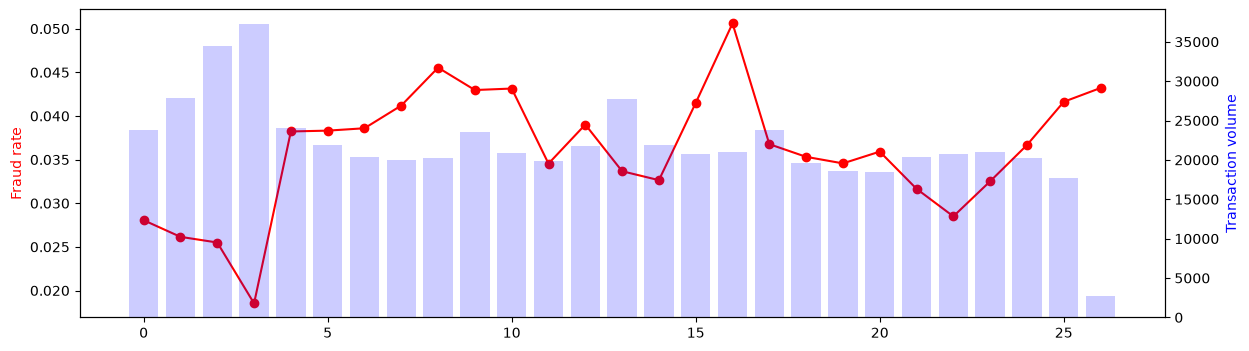

In [11]:
joined_df['TransactionDTDays']=joined_df['TransactionDT']//(24*3600)
weekly_fraud=joined_df.groupby(joined_df['TransactionDTDays']//7).agg(
    fraud_rate=('isFraud', 'mean'),
    volume=('isFraud', 'count')
)

fig, ax1 = plt.subplots(figsize=(14,4))
ax1.plot(weekly_fraud.index, weekly_fraud['fraud_rate'], color='red', marker='o')
ax1.set_ylabel('Fraud rate', color='red')

ax2 = ax1.twinx()
ax2.bar(weekly_fraud.index, weekly_fraud['volume'], alpha=0.2, color='blue')
ax2.set_ylabel('Transaction volume', color='blue')

Week 3 — the volume/fraud-rate relationship works exactly as expected. This is the tallest bar (highest volume, 35K) and it lines up with the lowest fraud rate (0.019). That's not a coincidence to be suspicious of — a genuine volume surge (likely a shopping event — Black Friday/Cyber Monday territory, given this dataset covers roughly Oct–May) usually dilutes the fraud rate simply because legitimate transaction volume spiked faster than fraud did. This is a stable, trustworthy low point precisely because it sits on a large sample — worth a one-line note in your EDA write-up.

Week 16 — this is the one to actually investigate, not just report. It's the highest fraud rate (~0.051) and it sits on a moderate bar, similar in size to most of the surrounding weeks — not a thin, low-volume outlier. By the SE logic from before, that makes it a more credible signal than a spike sitting on a short bar would be. Worth digging into: what's different about that week's transactions? Check ProductCD mix, card types, or V-block patterns for that window specifically — if something concrete shows up, that's a genuinely useful finding for your README, not noise you should wave away.

Week 26 — treat this one as an edge artifact, not a data point. The volume craters to almost nothing (~2K vs ~20-25K everywhere else). Six months doesn't divide evenly into whole weeks, so this is almost certainly a truncated partial week at the dataset's boundary, not a real trend. I'd exclude it from any "fraud rate is rising toward the end" narrative — otherwise you're reading a sample-size artifact as a trend, exactly the trap this exercise is meant to catch.

Overall shape: baseline hovers around 0.033–0.045 with real week-to-week fluctuation, no strong long-term drift once you drop week 26. That's actually a useful thing to note for Day 3 — it means the time-based split isn't fighting a huge trend shift, just normal short-term variance, so if your time-split AUC comes in meaningfully lower than the random-split AUC, that gap is more likely coming from the pseudo-UID leakage across the split than from an actual regime change in fraud behavior over the six months.

In [16]:
# investigating week 16
import math

# create function to plot distribution for different time period
def plot_distr_transactionDT(startday, endday, df, num_features, cat_features, max_cols=4):
  df_period = df[(df['TransactionDTDays']>=startday)&(df['TransactionDTDays']<=endday)].copy()
  # numeric features
  if num_features:
    n_cols = min(len(num_features), max_cols)
    n_rows = math.ceil(len(num_features) / n_cols) # round up to the nearest number
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5*n_cols, 4*n_rows))
    axes_flat=axes.flatten()
    for i, col in enumerate(num_features):
      ax=axes_flat[i]
      ax.set_xscale('linear')  # Reset scale to avoid log inheritance
      sns.histplot(
          data=df_period,
          x=col,
          hue='isFraud',
          #kde=True,
          stat='density',
          ax=ax
      )
      ax.set_title(f'Distr {col} (Days {startday}-{endday})')

      if col in ['TransactionAmt', 'dist1', 'C1', 'C2']:
        ax.set_xscale('log')
        ax.set_xlabel(f'{col} (log scale)')
      if ax.get_legend() is not None:
        sns.move_legend(ax, 'upper right')

    for j in range(len(num_features), len(axes_flat)):
      axes_flat[j].set_visible(False)
    plt.tight_layout()
    plt.show()

  # categorical features
  if cat_features:
    n_cols = min(len(cat_features), max_cols)
    n_rows = math.ceil(len(cat_features) / n_cols) # round up to the nearest number
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5*n_cols, 4*n_rows))
    axes_flat=axes.flatten()

    for i, col in enumerate(cat_features):
      ax=axes_flat[i]
      ax.set_xscale('linear')  # Reset scale to avoid log inheritance

      sub = df_period[[col, 'isFraud']].dropna(subset=[col]).copy()
      sub[col] = sub[col].astype(str)
      if sub.empty:
        ax.set_title(f'{col}\n(All NaN)')
        continue

      top_cat=sub[col].value_counts().nlargest(10).index.tolist()
      plot_data=sub[sub[col].isin(top_cat)]

      sns.countplot(
          data=plot_data,
          x=col,
          hue='isFraud',
          order=top_cat,
          ax=ax
      )
      ax.set_title(f'Distr {col} (Days {startday}-{endday})')
      if ax.get_legend() is not None:
        sns.move_legend(ax, 'upper right')

    for j in range(len(cat_features), len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.tight_layout()
    plt.show()




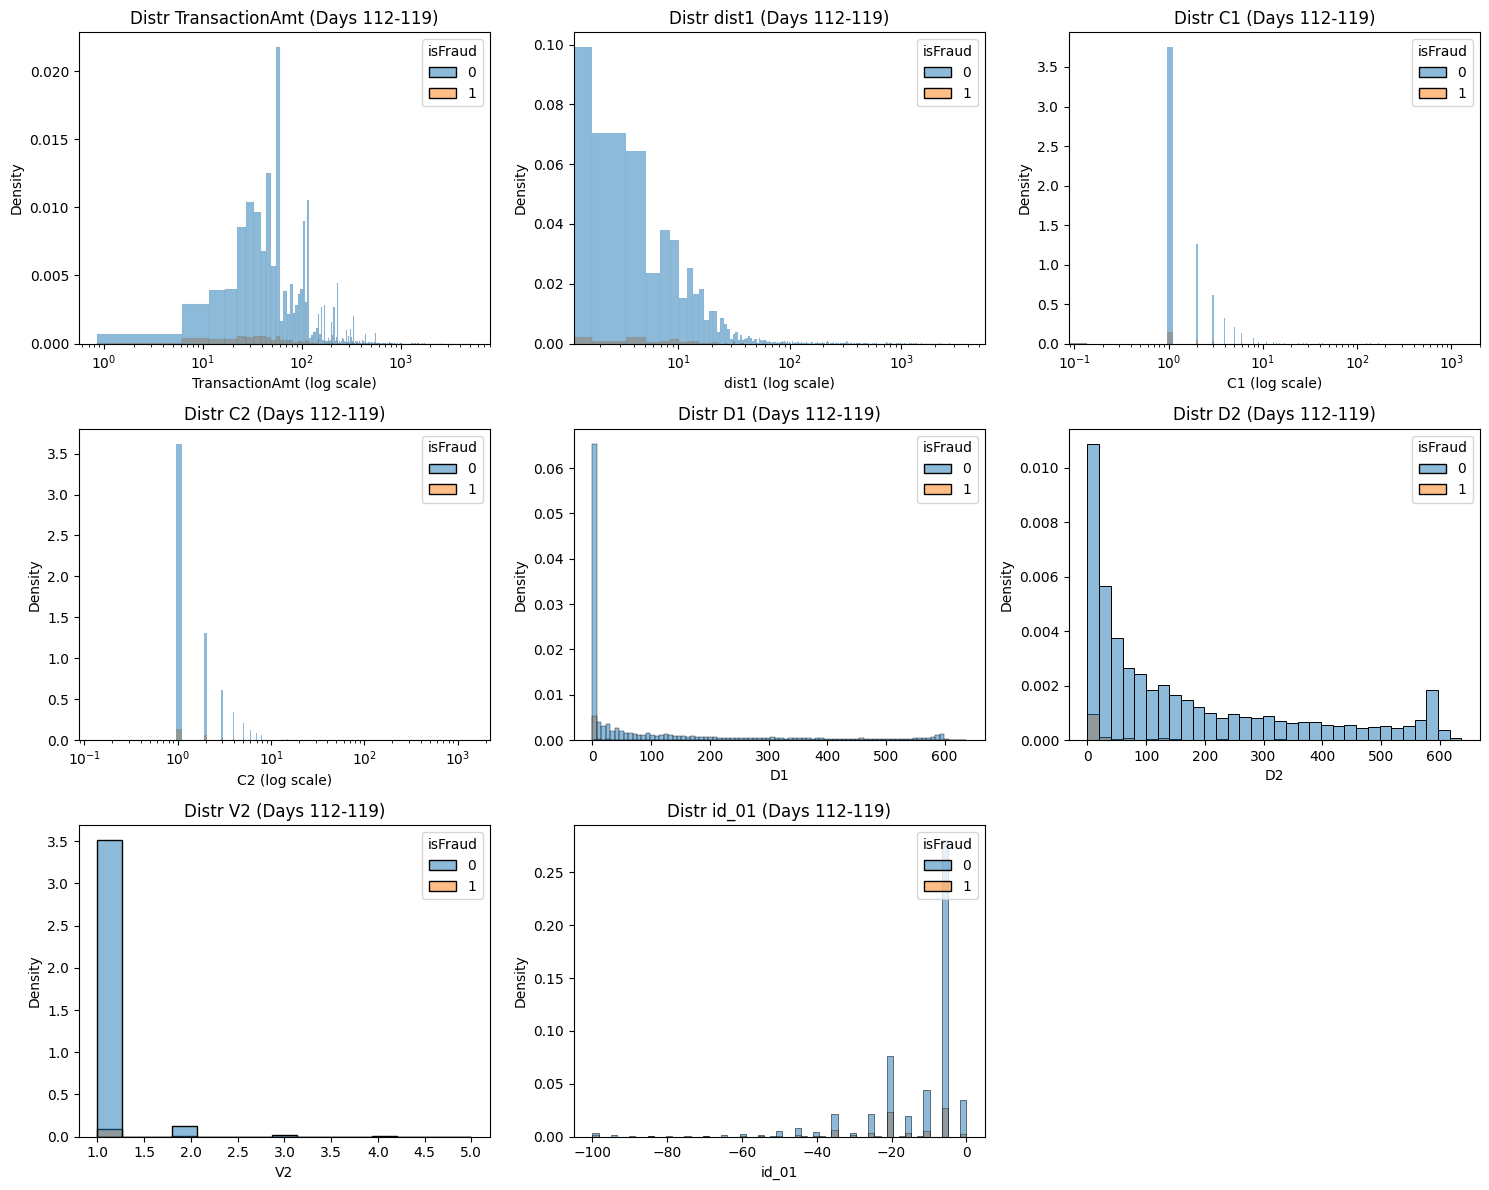

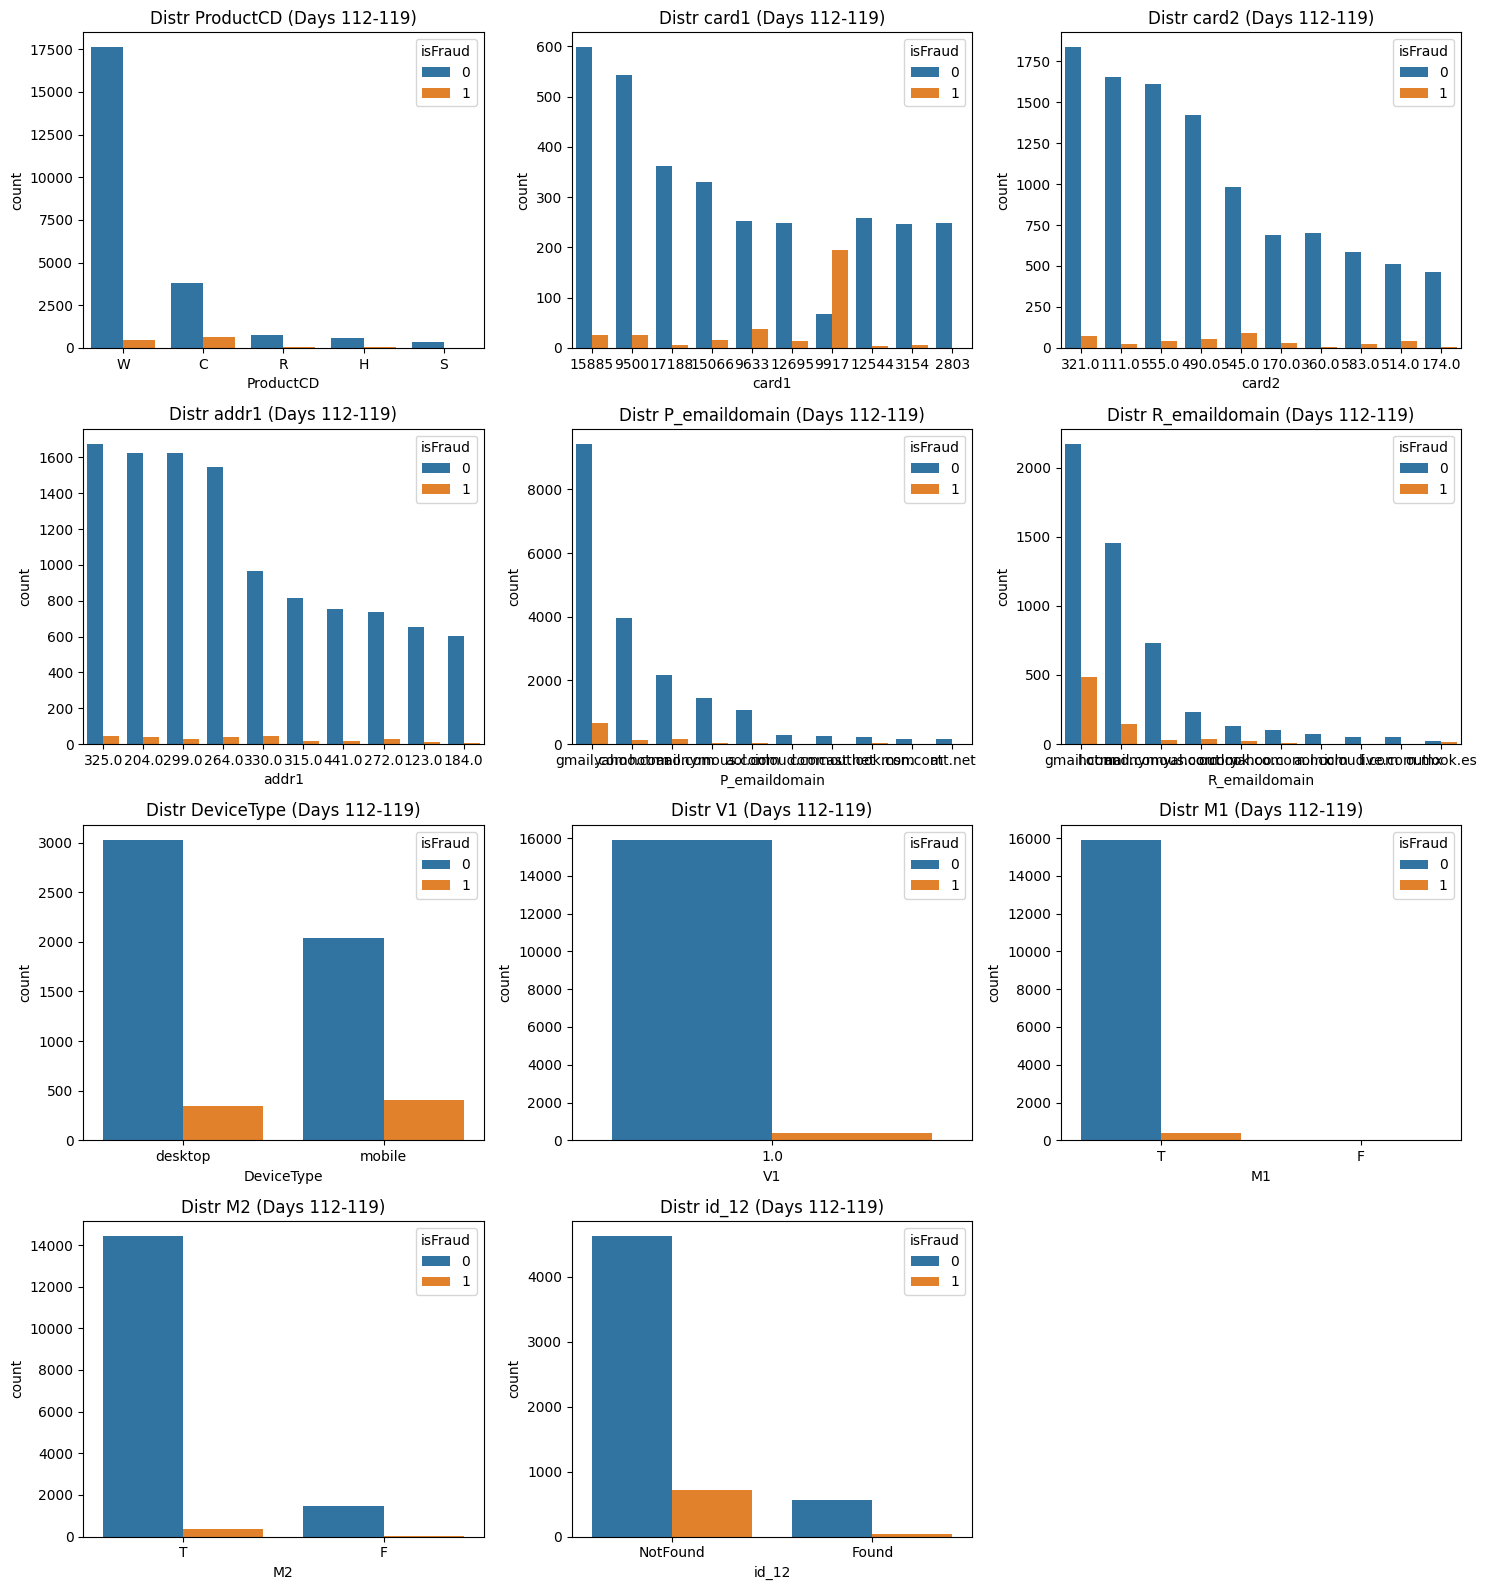

In [17]:
num_feat=['TransactionAmt', 'dist1', 'C1', 'C2', 'D1', 'D2', 'V2', 'id_01']
cat_feat=['ProductCD', 'card1', 'card2', 'addr1', 'P_emaildomain', 'R_emaildomain','DeviceType', 'V1', 'M1', 'M2', 'id_12']
plot_distr_transactionDT( 112, 119, joined_df, num_feat, cat_feat, max_cols=3)

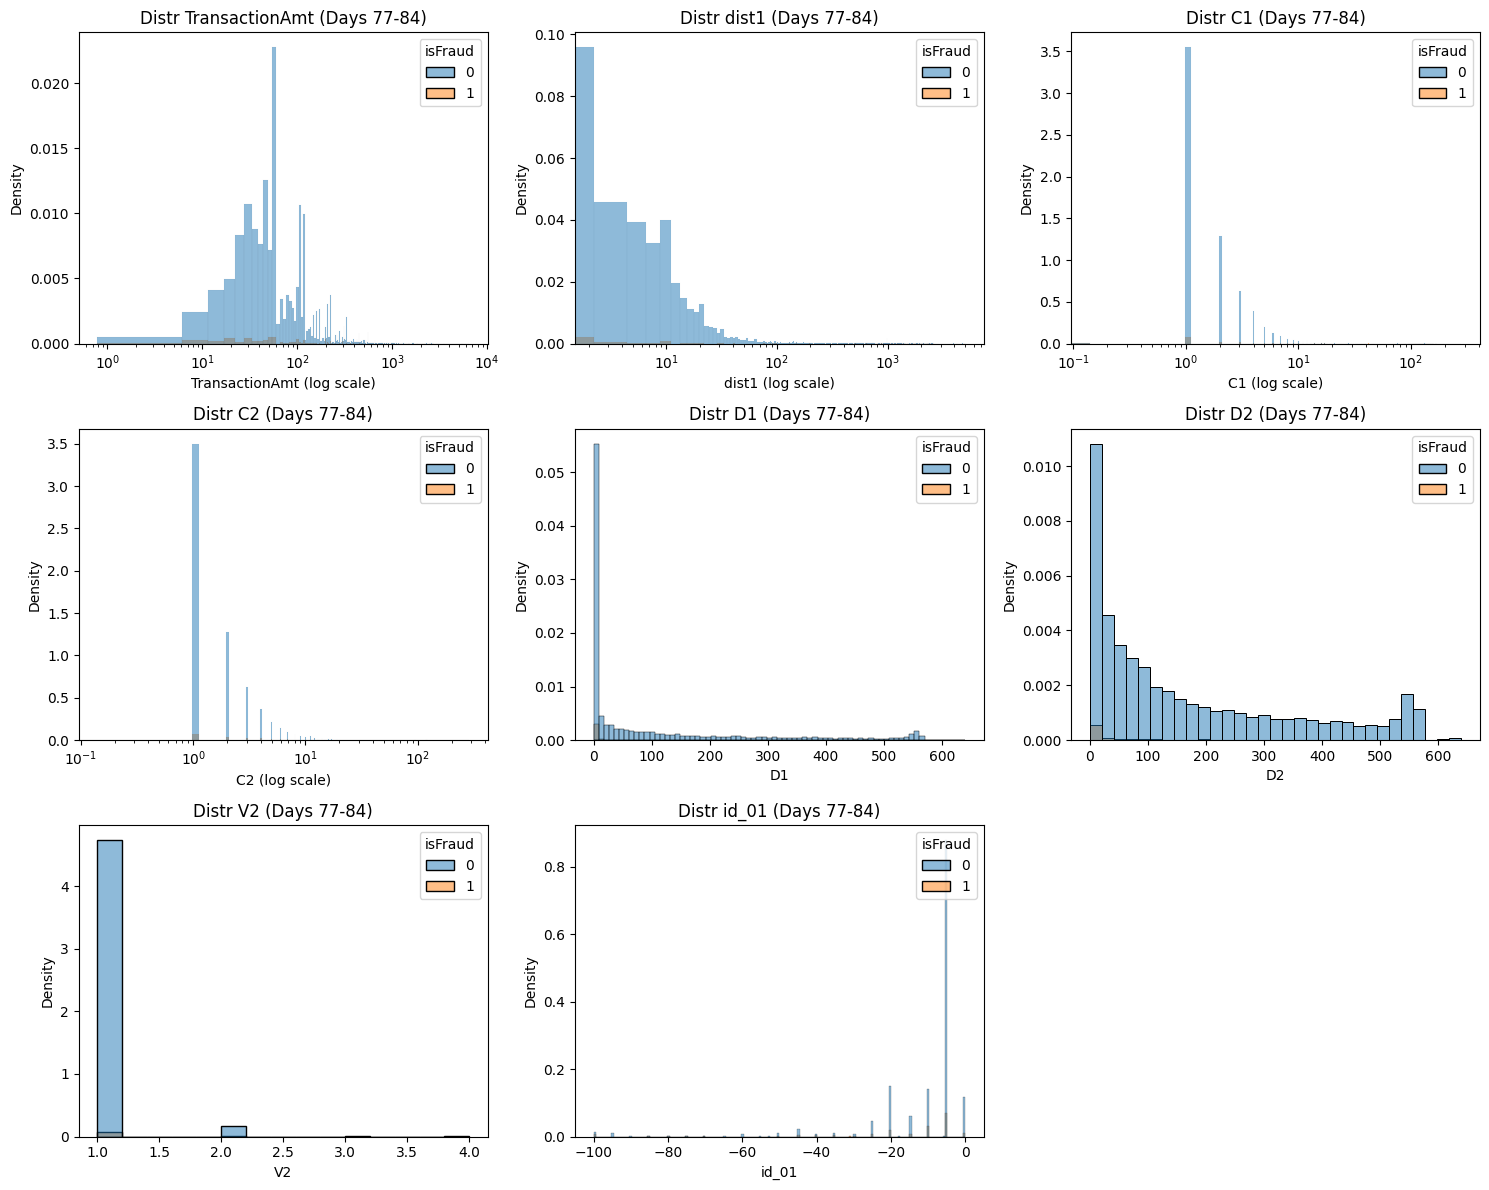

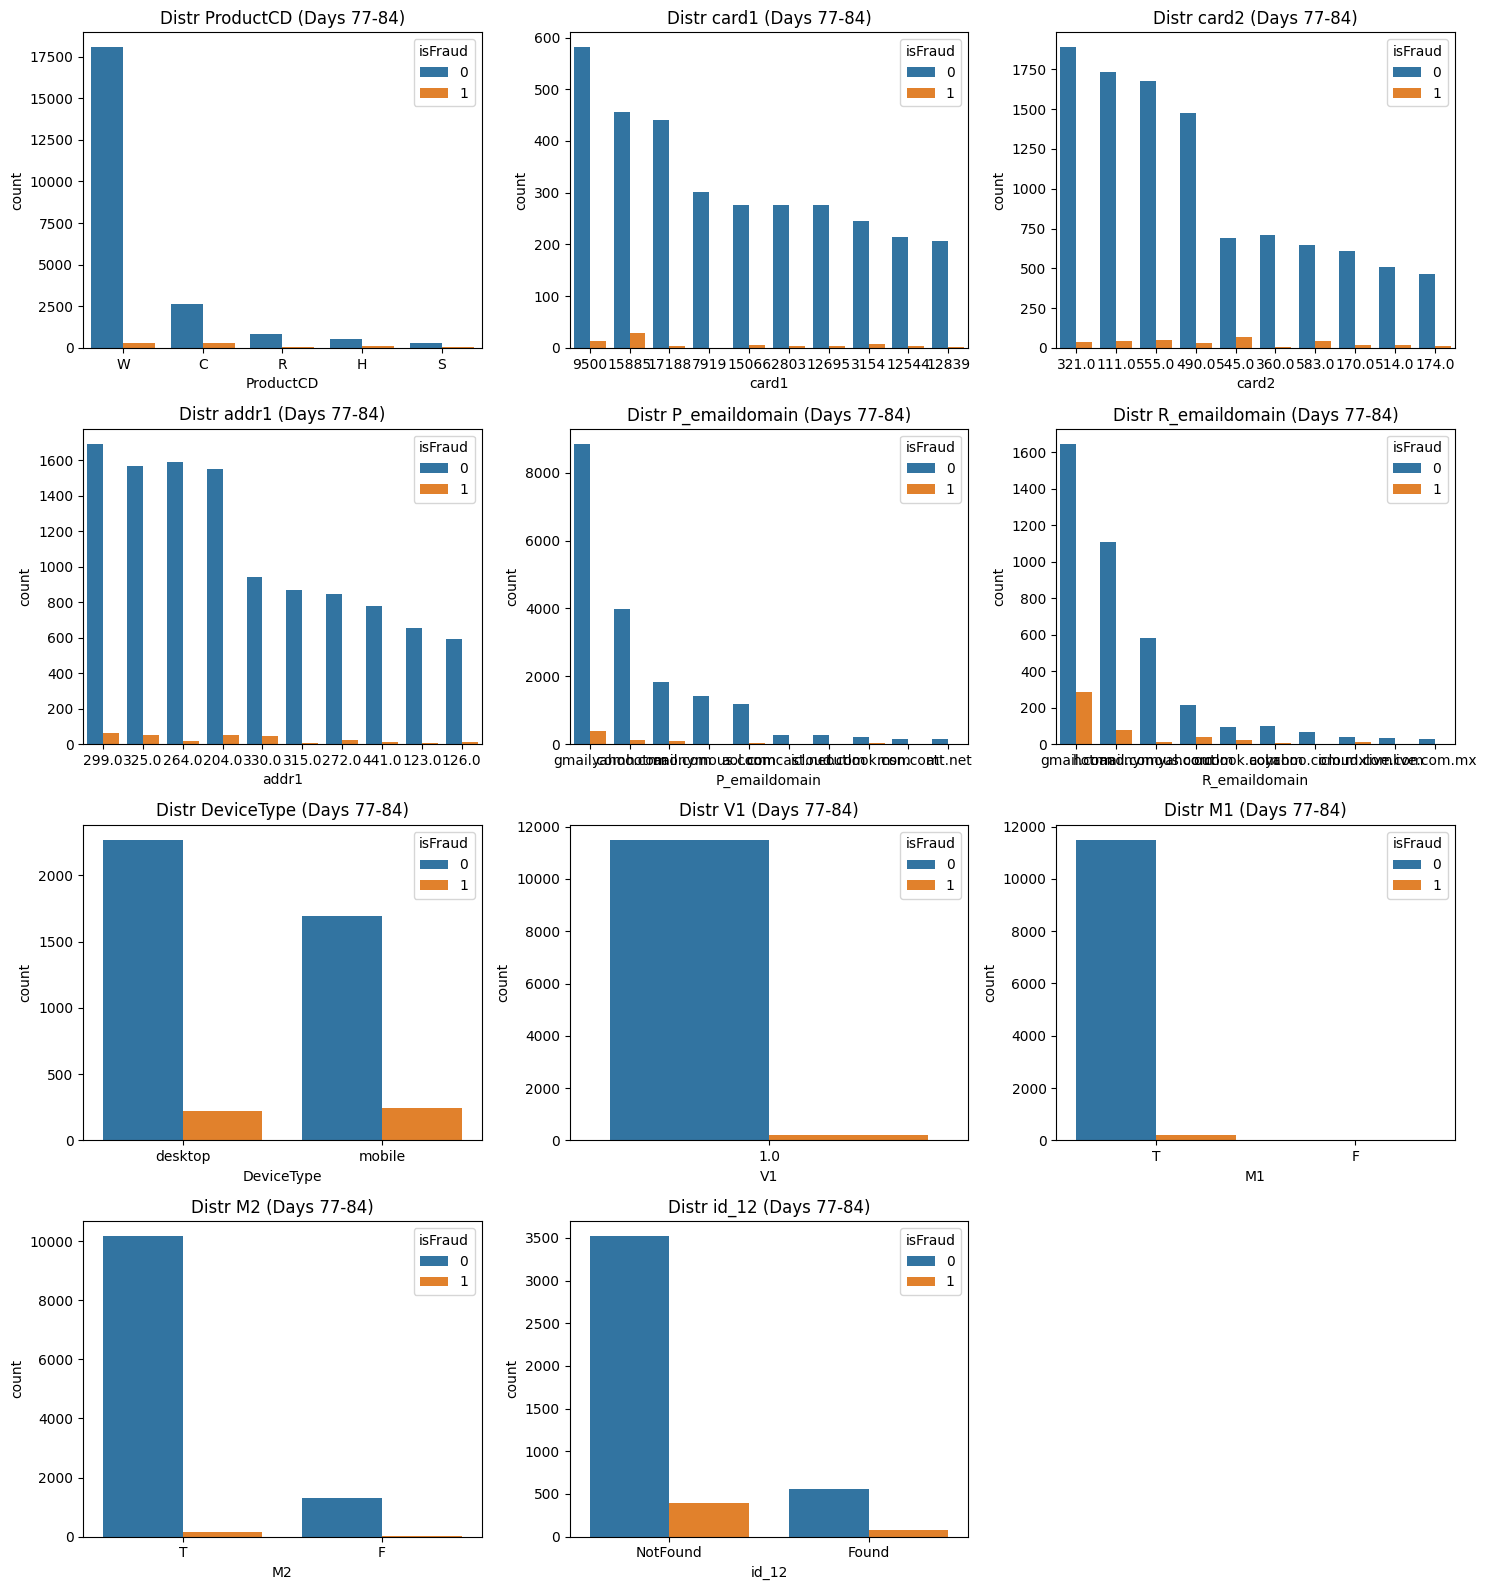

In [18]:
plot_distr_transactionDT( 77, 84, joined_df, num_feat, cat_feat, max_cols=3)

Compared week 16 (more fraud rate) and week 11 (medium fraud rate).  
It was noticed that during high fraud rate on week 16 card1 feature 9917 has more fraud than no-fraud, so it has to be further inspected.  
Also, gmail domains are tend to be more used for fraud.

In [19]:
# plot fraud rate per category for exact period

def plot_fraud_rate_plot(df, cat_features, startday, endday, max_cols=4):
  df_period = df[(df['TransactionDTDays']>=startday)&(df['TransactionDTDays']<=endday)].copy()

  cols_count = min(len(cat_features), max_cols)
  rows_count = math.ceil(len(cat_features) / cols_count)

  fig, axes = plt.subplots(nrows=rows_count, ncols=cols_count, figsize=(5 * cols_count, 4 * rows_count), squeeze=False)
  axes_flat = axes.flatten()

  for i, col in enumerate(cat_features):
    ax=axes_flat[i]
    rate_df = (
          df_period.groupby(col)['isFraud']
          .agg(['mean', 'count'])
          .query('count > 50')  # filter out rare noise
          .sort_values(by='mean', ascending=False)
          .head(10)
          .reset_index()
      )
    rate_df[col] = rate_df[col].astype(str)

    sns.barplot(data=rate_df, x=col, y='mean', color='blue', order=rate_df[col], ax=ax)
    ax.set_title(f'{col} Fraud Rate (Days {startday}-{endday})')
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=45)

  for j in range(len(cat_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

  plt.tight_layout()
  plt.show()

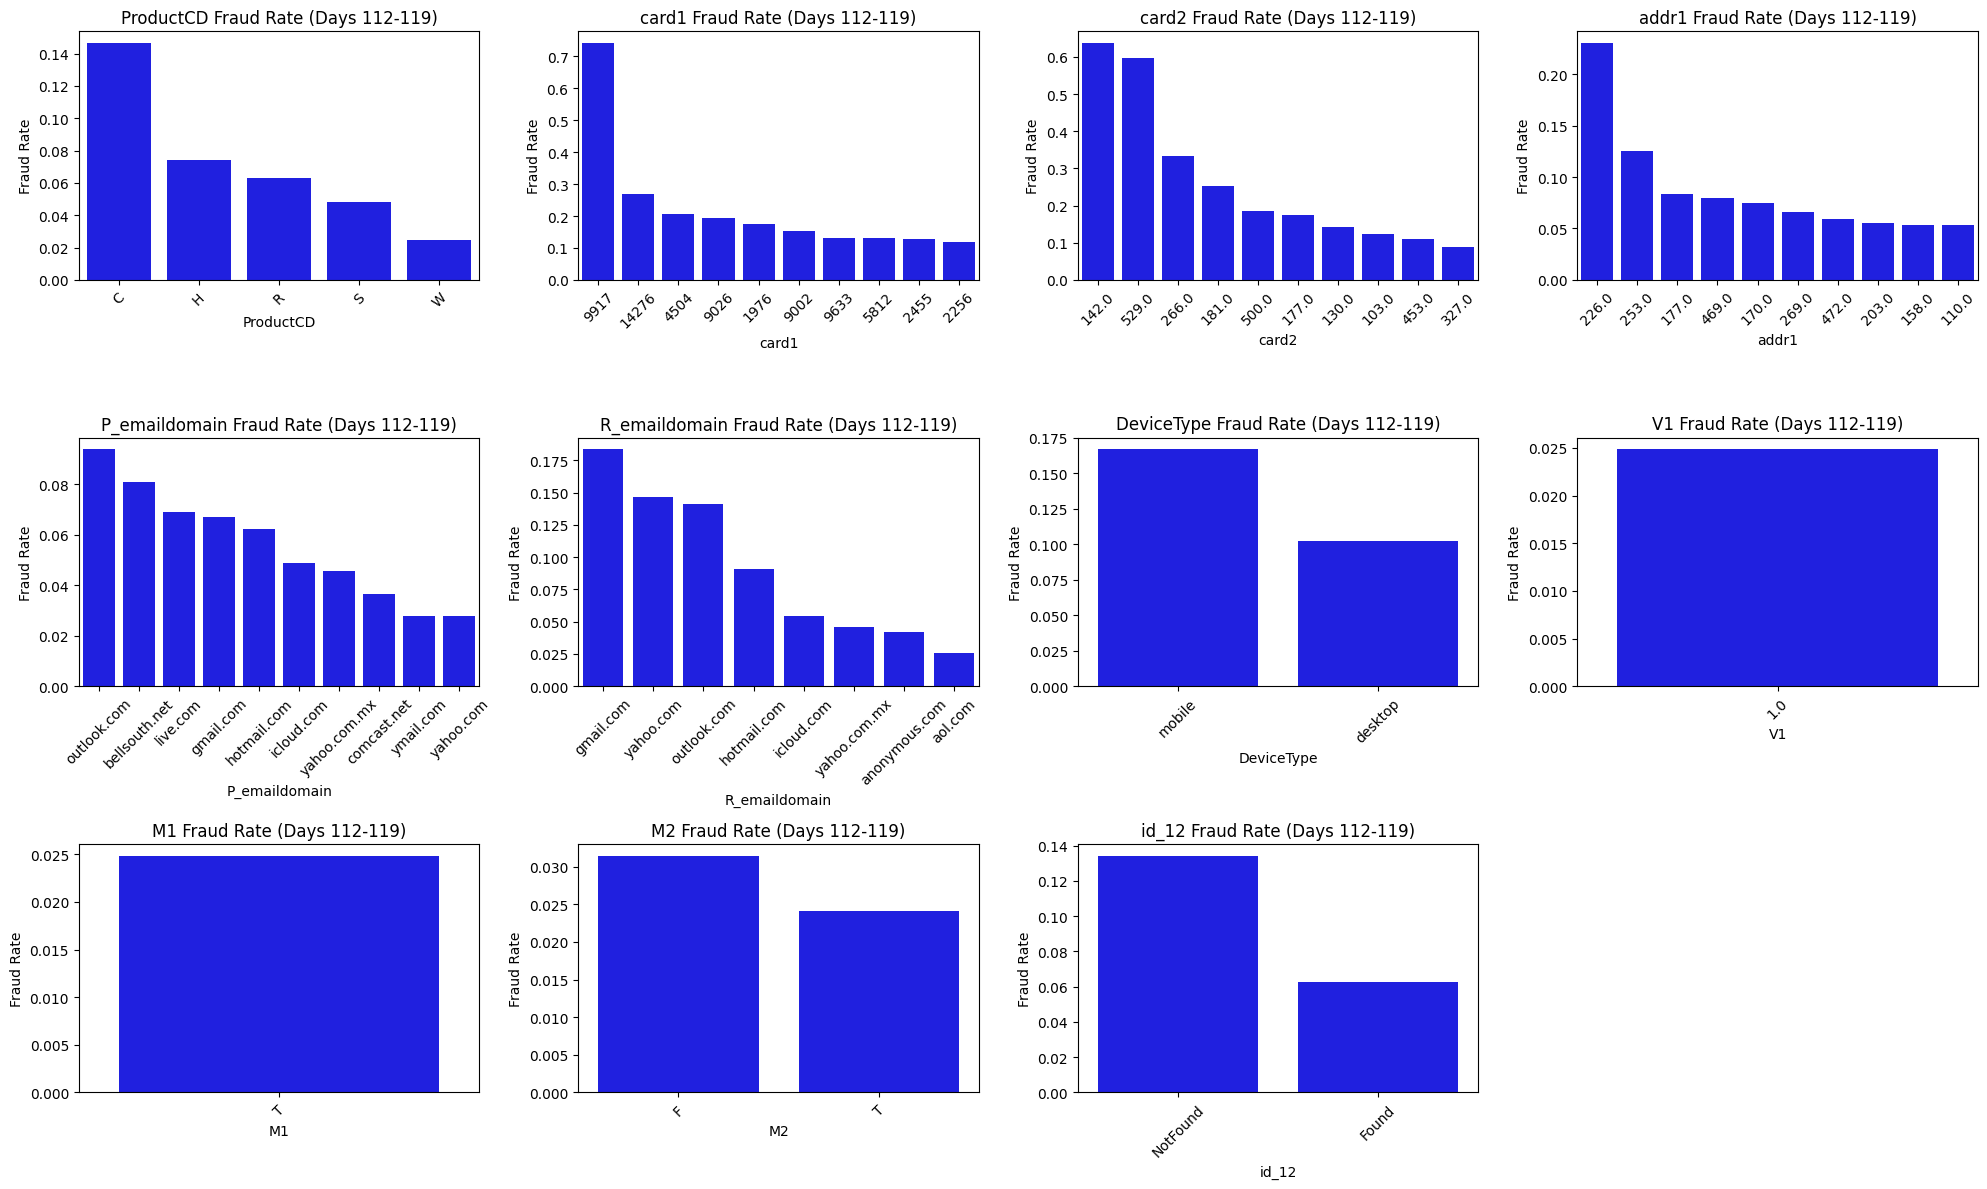

In [20]:
plot_fraud_rate_plot(joined_df, cat_feat, 112, 119)

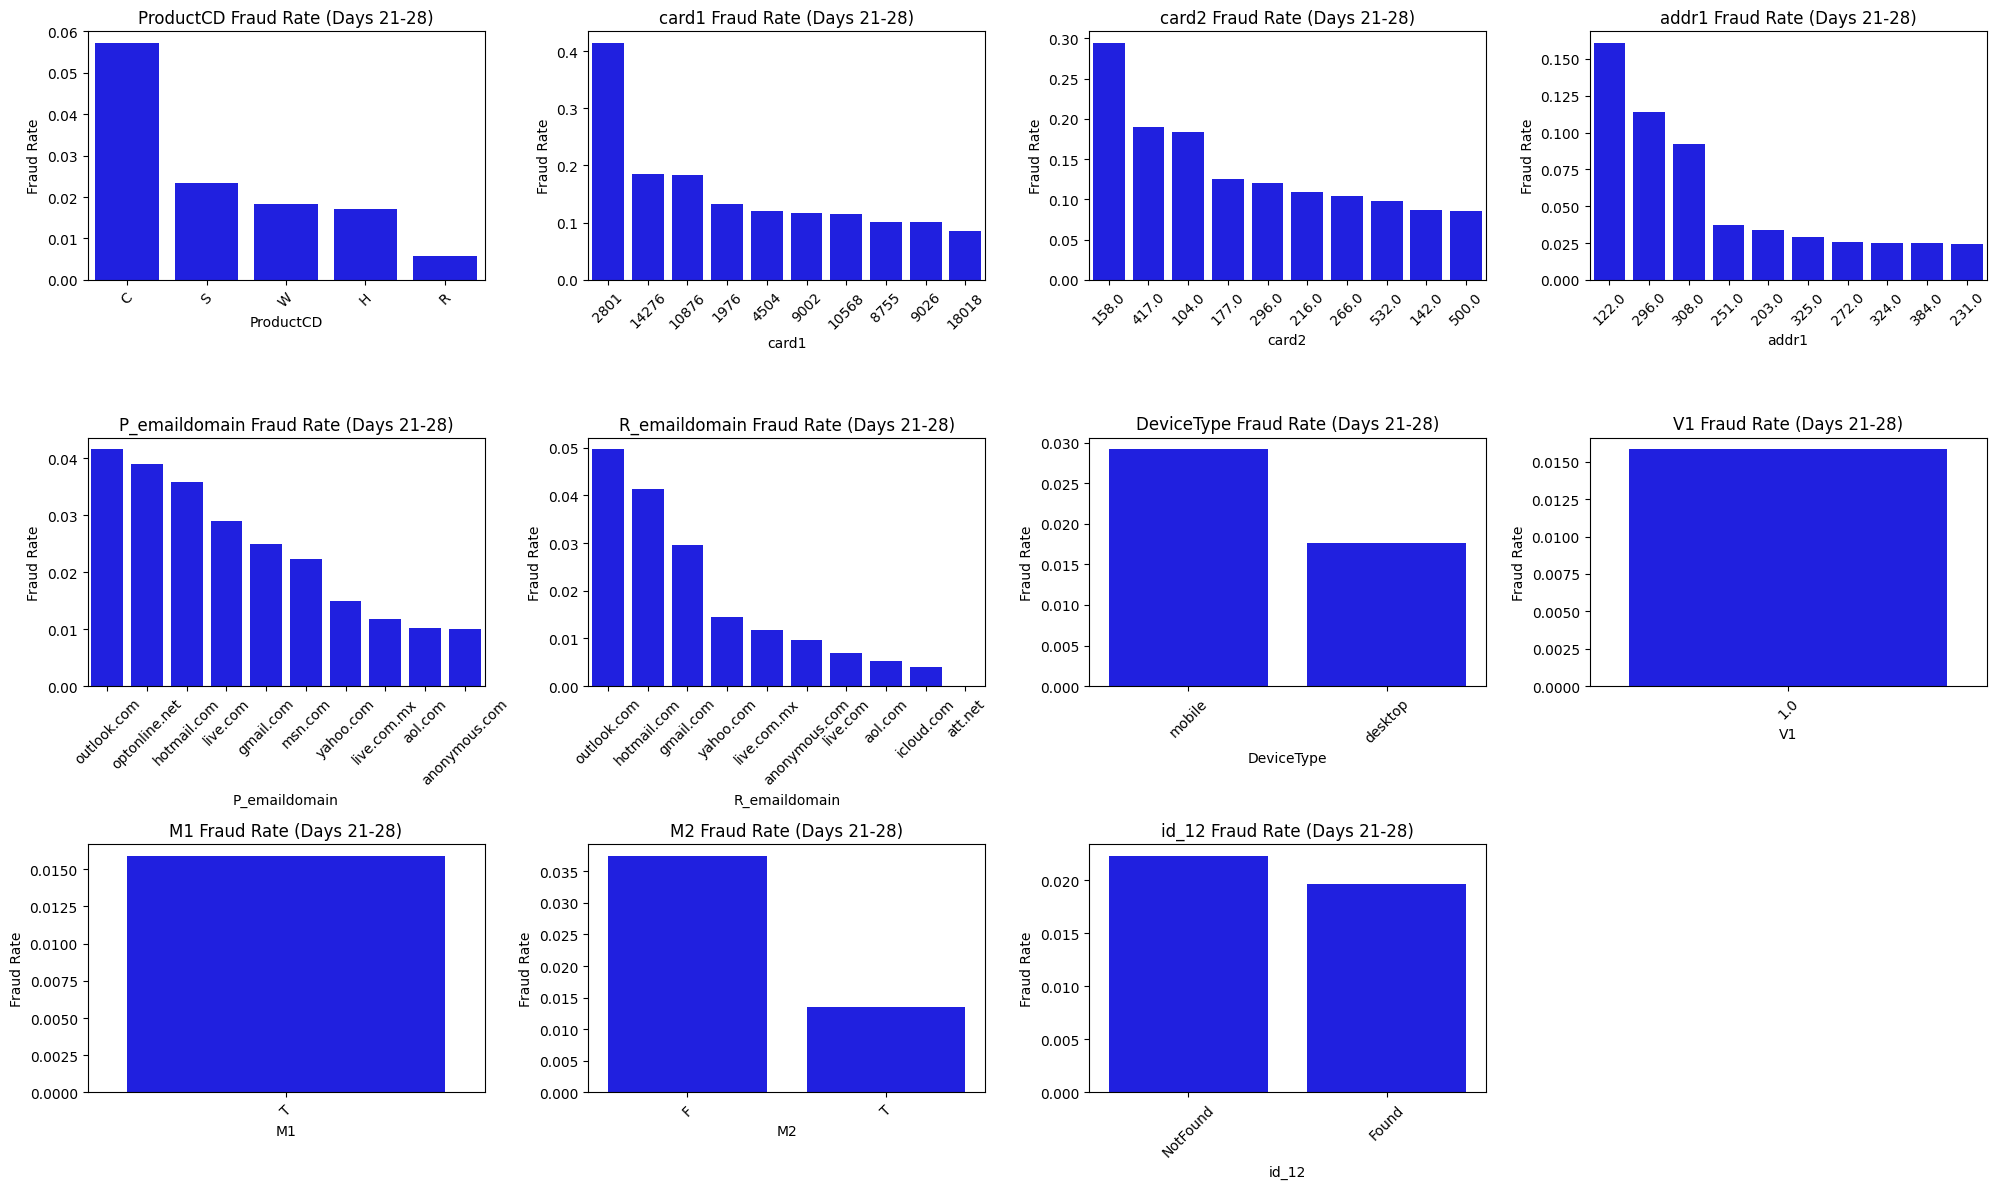

In [21]:
plot_fraud_rate_plot(joined_df, cat_feat, 21, 28)

As wee see if fraud rate comparing high fraud week with low fraud week:  
- product H is more likely to fraudulent  
- we have to check 9917 card1 for additional patterns  
- bellsouth.net is highly likely malitious and has to be checked  
- gmail is just in general the most used domain, as well as for fraud usage  
- Device type is not telling anything - mobile transactions prevail everywhere  
- id_12 might also be a flag: during fraud week proportion of not found to Found is much bigger, than during week 3.  

In [31]:
joined_df[joined_df.card1==9917]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,datetime,TransactionDTDays
672,2987672,0,99170,25.375999,C,9917,142.0,185.0,visa,138.0,debit,NaN,NaN,NaN,134.0,gmail.com,gmail.com,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,355.125000,0.125000,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,M0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0000,0.000000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,305278.0,0.0,0.0,0.0,-6.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-360.0,Found,Found,225.0,NaN,290.0,401.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,ie 11.

<Axes: >

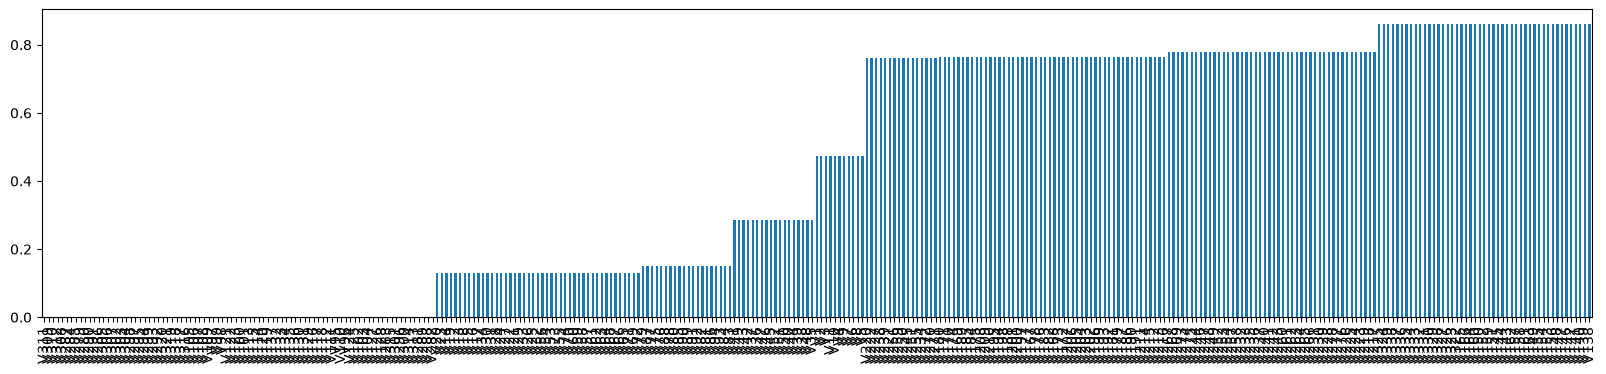

In [12]:
# assessing V features by missingness of information
v_cols = [c for c in joined_df.columns if c.startswith('V')]
missing_pct = joined_df[v_cols].isnull().mean().sort_values()
missing_pct.plot(kind='bar', figsize=(20,4))

The V columns aren't uniform — they come from different underlying feature groups with different missingness patterns.  
Group v_cols by clusters — each group is a missingness block. Record which transactions have each block present (often tied to ProductCD or payment card network)

In [13]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

v_cols=[col for col in joined_df.columns if col.startswith('V')]

sample_n = min(len(joined_df), 100_000)
sample_df = joined_df[v_cols].sample(n=sample_n, random_state=42)

# 2. Extract boolean array directly as uint8 or float32 (saving 8x memory)
mask_np = sample_df.isna().to_numpy(dtype=np.float32)

# 3. Use NumPy's corrcoef across columns (transpose so columns are variables)
# np.corrcoef is in-place C-level computation and uses a fraction of RAM
miss_corr = np.corrcoef(mask_np, rowvar=False)

# 4. Handle columns that have zero variance (all missing or none missing)
miss_corr = np.nan_to_num(miss_corr, nan=0.0)

# 5. Build hierarchy
dist = 1 - np.abs(miss_corr)
np.fill_diagonal(dist, 0)  # Ensure exact zeros on diagonal for squareform

condensed = squareform(dist, checks=False)
Z = linkage(condensed, method='average')
clusters = fcluster(Z, t=0.3, criterion='distance')

In [14]:
# group v_cols by clusters
cluster_series = pd.Series(clusters, index=v_cols, name='cluster_id')
v_clusters = cluster_series.groupby(cluster_series).groups # creates a dictionary
v_clusters

{1: ['V279', 'V280', 'V284', 'V285', 'V286', 'V287', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V297', 'V298', 'V299', 'V302', 'V303', 'V304', 'V305', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321'], 2: ['V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52'], 3: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11'], 4: ['V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V

Because features within a block are either present together or missing together, checking whether any (or all) features in the cluster are non-null gives a binary indicator ($1 = \text{present}$, $0 = \text{missing}$) for each transaction.

In [15]:
block_presence=pd.DataFrame(index=joined_df.index)
for id, cols in v_clusters.items():
  block_presence[f'block_{id}_present']=joined_df[cols].notna().any(axis=1).astype(int)
block_presence


,block_1_present,block_2_present,block_3_present,block_4_present,block_5_present,block_6_present,block_7_present
0,1,0,1,0,1,1,1
1,1,1,0,0,1,1,1
2,1,1,1,0,1,1,1
3,1,1,0,0,1,1,1
4,1,0,0,1,1,1,1
...,...,...,...,...,...,...,...
590535,1,0,1,0,1,1,1
590536,1,1,1,0,1,1,1
590537,1,1,1,0,1,1,1
590538,1,1,1,0,1,1,1


In [16]:
for col in block_presence.columns:
    joined_df[col] = block_presence[col].astype('bool')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9996\1339113444.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined_df[col] = block_presence[col].astype('bool')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9996\1339113444.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined_df[col] = block_presence[col].astype('bool')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9996\1339113444.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

In [17]:
block_cols=block_presence.columns.tolist()
# block presence by ProductCD
product_group_presence=joined_df.groupby('ProductCD')[block_cols].mean().round(2)
# block presence by card4 (visa vs mastercard)
card4_group_presence=joined_df.groupby('card4')[block_cols].mean().round(2)

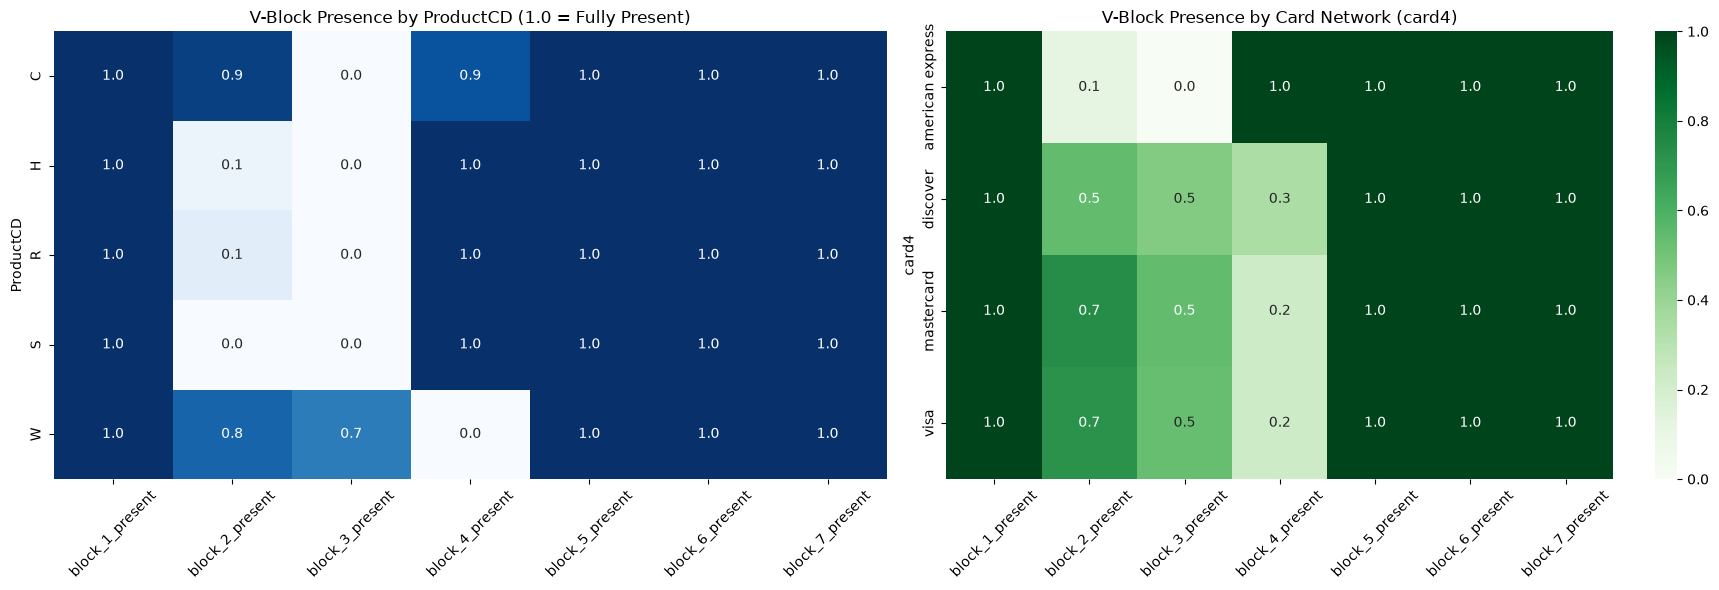

In [18]:
# visualize

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    product_group_presence,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("V-Block Presence by ProductCD (1.0 = Fully Present)")
axes[0].set_ylabel("ProductCD")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    card4_group_presence,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("V-Block Presence by Card Network (card4)")
axes[1].set_ylabel("card4")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The left plot reveals strict mutual exclusivity between products:

block_3 is exclusive to Product W (0.7): Products C, H, R, and S have an exact 0.0 presence for block_3. This means whatever sub-service generated block_3 only exists on the W checkout flow.

block_4 is completely absent for Product W (0.0): Conversely, block_4 is evaluated almost 100% of the time for C (0.9), H (1.0), R (1.0), and S (1.0).

Takeaway: W uses a fundamentally different payment processing pipeline compared to H, R, and S

3. American Express Follows Non-Standard Protocols
Look at the right plot for american express:

It has 0.0 presence for block_3 and only 0.1 for block_2, while having 1.0 presence for block_4.

Meanwhile, Visa, Mastercard, and Discover behave similarly to one another (0.7 for block_2, 0.5 for block_3, 0.2 for block_4).

Takeaway: Amex acts as both the card network and the issuing bank (closed-loop network), so it bypasses traditional 3rd-party banking verification checks that Visa and Mastercard go through.

Feature Engineering: Instead of keeping 30+ collinear columns from cluster $k$, you can use a single binary flag v_block_k_present plus aggregated statistics (e.g., mean/max of that block) or keep just one representative feature

In [19]:
# Assume block_dict maps block name to its list of V-column names:
#block_dict = {name_block:value for name_block, value in zip()}

cols_to_drop = []

for _, cols in v_clusters.items():
    if len(cols) <= 1:
        continue

    # 1. Take rows where these features are present (sample up to 50k for speed/RAM)
    valid_rows = joined_df[cols].dropna()
    sample = valid_rows.sample(n=min(50_000, len(valid_rows)), random_state=42)

    # 2. Compute correlation matrix within the block
    corr_matrix = sample.corr().abs()

    # 3. Compare correlated pairs and drop the one with fewer unique values
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    for col in upper.columns:
        # Find features correlated with 'col' above 0.90
        correlated_features = upper.index[upper[col] > 0.90].tolist()

        for correlated in correlated_features:
            if correlated in cols_to_drop or col in cols_to_drop:
                continue

            # Keep the one with more unique values (more granular split potential)
            if sample[col].nunique() >= sample[correlated].nunique():
                cols_to_drop.append(correlated)
            else:
                cols_to_drop.append(col)

cols_to_drop = list(set(cols_to_drop))
print(f"Dropping {len(cols_to_drop)} collinear features out of {len(v_cols)}.")


Dropping 136 collinear features out of 339.


In [20]:
# Drop from dataset in-place
joined_df.drop(columns=cols_to_drop, inplace=True)

In [21]:
# drop block 1, 5, 6, 7 flag missingness
joined_df.drop(columns=['block_1_present','block_5_present','block_6_present','block_7_present'], inplace=True)

Produce one short EDA summary (markdown cell or README section) covering: fraud rate, number of V-blocks found and what distinguishes them, whether fraud rate drifts over time, and how many V-columns you're carrying forward after clustering. This becomes the first paragraph of your Fraud project README

In [ ]:
# Persist Pruned Dataset to Parquet
#%pip install pyarrow

output_path = os.path.join(interim_data_path, "pruned_eda.parquet")
joined_df.to_parquet(output_path, index=False, engine="pyarrow")
print(f"Successfully saved pruned dataset to {output_path} with shape {joined_df.shape}")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Successfully saved pruned dataset to ../data/interim\pruned_eda.parquet with shape (590540, 303)


: 